# Binary Classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem Statement

Given data from an insurance company in the form of customer details obtained from filling out an online form. As someone working in the insurance field, you are obliged to assess which customers are eligible for a loan and which are not, based on the history of previous customers. New data collected daily is continually increasing rapidly, making it impossible to check manually. You are asked to create an automated program that can predict whether new customers applying for a loan will experience payment difficulties or not. The data you have is as follows:<br>
Loan_ID : Nomor unik yang diberikan untuk setiap nasabah yang mengajukan pinjaman <br>
Gender : Jenis kelamin nasabah<br>
Married : Status pernikahan nasabah<br>
Dependents : Tanggungan nyawa yang harus ditanggung nasabah<br>
Education : Pendidikan terakhir nasabah<br>
Self_Employed : Status pekerjaan nasabah<br>
ApplicantIncome : Pendapatan nasabah yang mengajukan pinjaman<br>
CoapplicantIncome : Pendapatan pemohon bersama<br>
LoanAmount : Jumlah pinjaman yang diajukan <br>
Loan_Amount_Term : Jangka waktu pinjaman<br>
Credit_History : Riwayat kredit<br>
Property_Area : Kondisi area dari properti yang dimiliki pemohon<br>
Loan_Status : Status pinjaman yang dimiliki, berhutang atau tidak<br>

## 1. Import Libraries and Data

IMPORT PACKAGES

In [ ]:
# Import Package
import os
import pandas as pd
import numpy as np

# Package untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Package untuk cleaning, modelling, dan evaluation model
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
# Membuat path untuk mengidentifikasi letak directory
# Catatan : pastikan path yang anda masukkan sesuai dengan directory data anda. Kemungkinan besar path di contoh ini berbeda dengan penyimpanan data anda
path = '/content/drive/MyDrive/Data Notebook/'

IMPORT DATA

In [ ]:
# Load data
df = pd.read_csv(os.path.join(path, "loan_prediction.csv"), encoding='utf-8', index_col='Loan_ID')
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dari data diatas maka bisa didapat keterangan bahwa <br>
x = Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area <br>
y = Loan_Status

## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Cek informasi yang terdapat di data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, LP001002 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


Akan dicari tahu, apakah status orang yang meminjam lebih banyak dibandingkan yang tidak atau sebaliknya ?

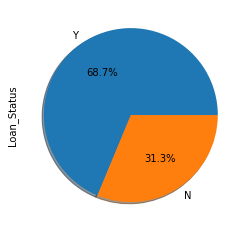

In [ ]:
# Mencari perbandingan label/class
df['Loan_Status'].value_counts().plot.pie(autopct='%1.1f%%',shadow=True)
plt.show()

Bisa dikatakan bahwa data masih tergolong balance. Status orang yang memiliki pinjaman tidak berbeda jauh dengan yang tidak meminjam.

In [ ]:
# Analisa deskriptif
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Apabila dilihat dari CoapplicantIncome didapat bahwa minimum income adalah 0 dan 0 pula di Q1. Akan dicari tahu apakah status pernikahan berpengaruh terhadap pencantuman besaran CoapplicantIncome?

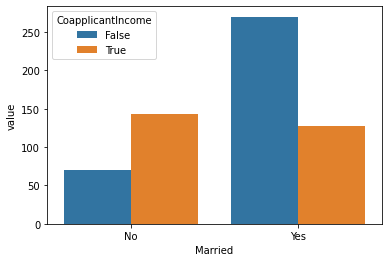

In [ ]:
# Buat Crosstab antara merried status dan coapplicant income
married_income = pd.crosstab(df['Married'], (df['CoapplicantIncome']==0))

# Buat hasil crosstab menjadi dataframe
stacked = married_income.stack().reset_index().rename(columns={0:'value'})
sns.barplot(x=stacked.Married, y=stacked.value, hue=stacked.CoapplicantIncome)
plt.show()

Dari hasil visualisasi diketahui bahwa orang yang telah menikah cenderung memiliki coapplicant income dibanding dengan yang belum menikah. Sedangkan orang yang belum menikah lebih banyak tidak memiliki coapplicant income dibanding yang mempunyai. Oleh karena itu diasumsikan bahwa applicant dan coapplicant adalah sepasang suami istri.
<br>
<br>
Apakah gender berpengaruh terhadap besarnya income antara applicant dan coapplicant ?

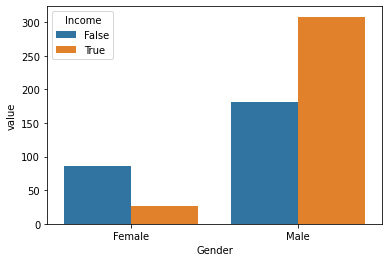

In [ ]:
# Cek antara income bagi yang telah menikah antara applicant dan coapplicant income
married_yes = pd.crosstab(df['Gender'], (df['Married']=='Yes') & (df['ApplicantIncome']>df['CoapplicantIncome']))

# Buat hasil crosstab menjadi dataframe
married_stacked = married_yes.stack().reset_index().rename(columns={0:'value', "col_0":"Income"})
married_stacked
sns.barplot(x=married_stacked.Gender, y=married_stacked.value, hue=married_stacked.Income)
plt.show()

Diketahui bahwa bagi orang yang sudah menikah, apabila pendapatan applicant > coapplicant rata-rata yang memenuhi kondisi tersebut adalah laki-laki, dan sebaliknya. Oleh karena itu diasumsikan apabila sudah menikah dan pendapatan applicant lebih tinggi maka dia adalah laki-laki. <br>
<br>
Lalu, bagaimana jika dengan yang belum menikah ?

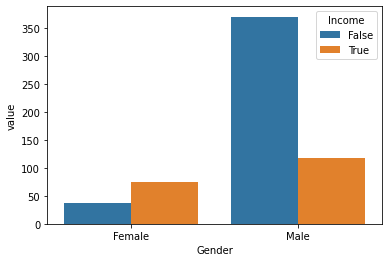

In [ ]:
# Cek antara income bagi yang belum menikah antara applicant dan coapplicant income
married_no = pd.crosstab(df['Gender'], (df['Married']=='No') & (df['ApplicantIncome']>df['CoapplicantIncome']))

# Buat hasil crosstab menjadi dataframe
married_stacked_no = married_no.stack().reset_index().rename(columns={0:'value', "col_0":"Income"})
sns.barplot(x=married_stacked_no.Gender, y=married_stacked_no.value, hue=married_stacked_no.Income)
plt.show()

Kodisi yang berbeda terjadi bagi orang yang belum menikah. Bagi orang yang belum menikah, apabila pendapatan applicant lebih tinggi maka dia adalah perempuan, dan sebaliknya.

Apakah ada pengaruh antara persetujuan status dengan status married dan gender applicant?

In [ ]:
status_loan = pd.crosstab([df['Married'], df["Gender"]], (df['Loan_Status']=='Y'))
status_loan

Loan_Status     False  True
Married Gender             
No      Female     29    51
        Male       49    81
Yes     Female      8    23
        Male      101   256

Dari hasil crosstab didapat bahwa status Loan tidak dapat ditentukan dari kedua komponen itu saja, masih banyak pengaruh lainnya.

Apakah ada kaitannya dengan beban tanggungan yang harus mereka tanggung?

In [ ]:
gender_dependent = pd.crosstab([df['Gender'], df["Married"]], (df['Dependents']=="0"))
gender_dependent

Dependents      False  True
Gender Married             
Female No          20    60
       Yes         11    20
Male   No          21   109
       Yes        208   149

dari hasil crosstab diketahui bahwa wanita baik yang belum dan sudah menikah kebanyakan tidak memiliki tanggungan nyawa yang harus ditanggung, berbeda dengan laki-laki, laki-laki yang sudah menikah menikah memiliki tanggungan nyawa yang harus ditanggung.<br>
Bagaimana pengaruh beban tanggungan terhadap pinjaman ?

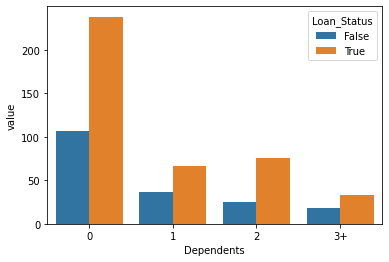

In [ ]:
# Cek tanggungan terhadap status pinjaman
loan_y = pd.crosstab(df['Dependents'], (df['Loan_Status'] == "Y"))

# Buat hasil crosstab menjadi dataframe
loan_stacked = loan_y.stack().reset_index().rename(columns={0:'value'})
sns.barplot(x=loan_stacked.Dependents, y=loan_stacked.value, hue=loan_stacked.Loan_Status)
plt.show()

Ternyata jumlah tanggungan tidak banyak mempengaruhi status pinjaman. Baik memiliki tanggungan dan tidak, user tetap meiliki tanggungan pinjaman.<br>
<br>
Bagaimana dengan status pekerjaan ?

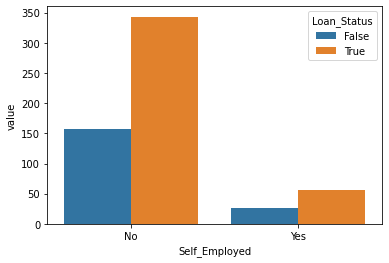

In [ ]:
# Cek status pekerjaan dan pinjaman
employ_y = pd.crosstab(df['Self_Employed'], (df['Loan_Status'] == "Y"))

# Buat hasil crosstab menjadi dataframe
employ_stacked = employ_y.stack().reset_index().rename(columns={0:'value'})
sns.barplot(x=employ_stacked.Self_Employed, y=employ_stacked.value, hue=employ_stacked.Loan_Status)

Jika dilihat dari status pekerjaan tidak banyak pula memberikan pengaruh ke status pinjaman.
<br>
<br>
Apakah ada perbedaan pendapatan applicant ?

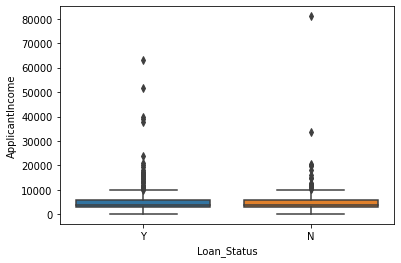

In [ ]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)

Jika dilihat dari distribusi pendapatan, tidak banyak berpengaruh juga.

## 3 Preprocessing

### 3.1. Missing value

In [ ]:
# cek missing value
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Dari hasil cek missing value diketahui bahwa terdapat beberapa data yang menggandung missing value, diantaranya : Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Ammount_Term, Credit_History. Variabel-variabel diatas tidak semua dapat diisi dengan mean, median, atau mode. Tidak juga dihilangkan karena missing value tergolong banyak, dan dapat mereduksi banyak data. Oleh karena itu akan dilakukan analisis mengisi missing value.

In [ ]:
# handdling missing value untuk married
# Membuat kondisi bagi missing value dengan keadaan coapllicant tidak kosong
married_status =((df['Married'].isnull()) & (df['CoapplicantIncome']!=0))

# Jika kondisi benar married dan memiliki coapplicant maka status menikah
df.loc[married_status, "Married"] = "Yes"
# Jika tidak memenuhi kondisi maka belum menikah
df.loc[df['Married'].isnull(),'Married'] = 'No'

In [ ]:
# Handdling missing value untuk gender
married_male = ((df['Gender'].isnull() & (df['Married']=='Yes')) & (df['ApplicantIncome']>df['CoapplicantIncome']))
married_female = ((df['Gender'].isnull() & (df['Married']=='Yes')) & (df['ApplicantIncome']<df['CoapplicantIncome']))
no_married_male = ((df['Gender'].isnull() & (df['Married']=='No')) & (df['ApplicantIncome']<df['CoapplicantIncome']))
no_married_female = ((df['Gender'].isnull() & (df['Married']=='No')) & (df['ApplicantIncome']>df['CoapplicantIncome']))


df.loc[married_male, "Gender"] = "Male"
df.loc[married_female, "Gender"] = "Female"
df.loc[no_married_male, "Gender"] = "Male"
df.loc[no_married_female, "Gender"] = "Female"

In [ ]:
# handdling missing value untuk Deppendent
# Membuat kondisi bagi missing value dengan keadaan tanggungan
dependents_male = (((df['Dependents'].isnull()) & (df['Gender']=="Male")) & (df['Married'] == "Yes"))

# Jika kondisi terpenuhi maka pilih modus
a = df[(df["Gender"] == "Male") & (df["Dependents"] != "0")]
a_1 = a["Dependents"].value_counts().index[0]
df.loc[dependents_male, "Dependents"] = a_1

# Jika tidak memenuhi kondisi maka tidak memiliki tanggungan
df.loc[df['Dependents'].isnull(),'Dependents'] = '0'

In [ ]:
# Selain itu akan diisi dengan modus dan mean untuk beberapa data seperti berikut ini
mmodus = ['Self_Employed','Credit_History']
mmean = ['LoanAmount','ApplicantIncome','CoapplicantIncome','Loan_Amount_Term']

for feature in mmean:
        if feature in df.columns.values:
            df[feature] = df[feature].fillna(df[feature].mean())

for feature in mmodus:
        if feature in df.columns.values:
            df[feature] = df[feature].fillna(df[feature].value_counts().index[0])

In [ ]:
# Cek kembali missing value
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

3.2 Label Encoder

In [ ]:
kategori = ['Gender','Married','Education','Self_Employed','Dependents','Credit_History', 'Property_Area','Loan_Status']
df_cat = df[kategori]
df_cat.head()

,Gender,Married,Education,Self_Employed,Dependents,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,
LP001002,Male,No,Graduate,No,0,1.0,Urban,Y
LP001003,Male,Yes,Graduate,No,1,1.0,Rural,N
LP001005,Male,Yes,Graduate,Yes,0,1.0,Urban,Y
LP001006,Male,Yes,Not Graduate,No,0,1.0,Urban,Y
LP001008,Male,No,Graduate,No,0,1.0,Urban,Y


In [ ]:
# Ubah kedalam bentuk numerik
encoded_data = LabelEncoder()

for feature in kategori:
        if feature in df.columns.values:
            df[feature] = encoded_data.fit_transform(df[feature])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1,2,1
LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1,0,0
LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1,2,1
LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1,2,1
LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1,2,1


### 3.3. Cek Korelasi

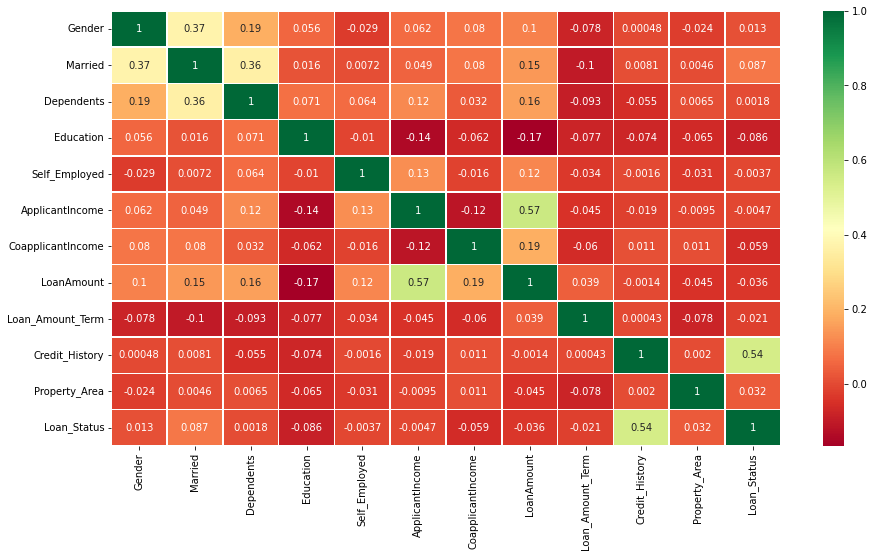

In [ ]:
# Melakukan perhitungan nilai korelasi dengan mengasumsikan data adalah data interval.
sns.heatmap(df.corr(),linewidths=.5,annot=True,cmap='RdYlGn')
fig=plt.gcf()
fig.set_size_inches(15,8)
plt.show()

In [ ]:
# Cek Urutan korelasi terendah ke tertinggi
korelasi = df.corr()["Loan_Status"].sort_values()
korelasi

Education           -0.085884
CoapplicantIncome   -0.059187
LoanAmount          -0.036416
Loan_Amount_Term    -0.020974
ApplicantIncome     -0.004710
Self_Employed       -0.003700
Dependents           0.001848
Gender               0.012646
Property_Area        0.032112
Married              0.086673
Credit_History       0.540556
Loan_Status          1.000000
Name: Loan_Status, dtype: float64

## 4. Feature Engineering

Dalam proses Feature Engineering, untuk case ini akan ditambahkan feature/variabel baru diantaranya:
TotalIncome : Total income didapat dengan menjumlahkan income antara applicant dan co-applicant. Jumlah pendapatan nasabah yang mengajukan pinjaman.<br>
Loan/Income : Rasio antara hutang dan pendapatan. Feature/variabel ini digunakan untuk mencari tahu persentase hutang yang dimiliki, balanced atau tidak dengan total pendapatan. Semakin kecil rasionya maka semakin kecil resiko yang dimiliki.<br>
Loan/Term : Rasio antara pinjaman dan jangka waktu pembayaran. Besarnya pendapatan yang dibayarkan nasabah dalam kurun waktu tertentu. <br>
RepaymentRatio : Metrik keuangan yang menunjukkan proporsi pendapatan yang dibayarkan nasabah yang dinyatakan sebagai persentase dari total pendapatannya.

In [ ]:
# Menambahkan variabel baru dari beberapa variabel yang sudah ada
df['TotalIncome']=df['ApplicantIncome']+df['CoapplicantIncome']
df['Loan/Income']=df['LoanAmount']/df['TotalIncome']
df['Loan/Term']=df['LoanAmount']/df['Loan_Amount_Term']
df['RepaymentRatio']=(df['Loan/Term']*1000)/df['TotalIncome']

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Loan/Income,Loan/Term,RepaymentRatio
Loan_ID,,,,,,,,,,,,,,,,
LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1,2,1,5849.0,0.025032,0.406700,0.069533
LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1,0,0,6091.0,0.021015,0.355556,0.058374
LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1,2,1,3000.0,0.022000,0.183333,0.061111
LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1,2,1,4941.0,0.024287,0.333333,0.067463
LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1,2,1,6000.0,0.023500,0.391667,0.065278


SCALING
<br>
Scaling dibutuhkan karena terdapat perbedaan range nilai yang tinggi diantara beberapa variabel.

In [ ]:
transformation_svm = MinMaxScaler().fit(df[['ApplicantIncome','CoapplicantIncome','LoanAmount','TotalIncome','Loan_Amount_Term']])
df[['ApplicantIncome','CoapplicantIncome','LoanAmount','TotalIncome','Loan_Amount_Term']]=transformation_svm.transform(df[['ApplicantIncome','CoapplicantIncome','LoanAmount', 'TotalIncome','Loan_Amount_Term']])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Loan/Income,Loan/Term,RepaymentRatio
Loan_ID,,,,,,,,,,,,,,,,
LP001002,1,0,0,0,0,0.070489,0.000000,0.198860,0.74359,1,2,1,0.055394,0.025032,0.406700,0.069533
LP001003,1,1,1,0,0,0.054830,0.036192,0.172214,0.74359,1,0,0,0.058435,0.021015,0.355556,0.058374
LP001005,1,1,0,0,1,0.035250,0.000000,0.082489,0.74359,1,2,1,0.019583,0.022000,0.183333,0.061111
LP001006,1,1,0,1,0,0.030093,0.056592,0.160637,0.74359,1,2,1,0.043980,0.024287,0.333333,0.067463
LP001008,1,0,0,0,0,0.072356,0.000000,0.191027,0.74359,1,2,1,0.057292,0.023500,0.391667,0.065278


## 5. Membangun Model Klasifikasi

MEMBAGI TRAIN TEST DATA

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X Train : ", len(X_train))
print("y Train : ", len(y_train))
print("X Test : ", len(X_test))
print("t Test : ", len(y_test))

X Train :  429
y Train :  429
X Test :  185
t Test :  185


### Stats Model (Logistic Regression)

In [ ]:
Input = sm.add_constant(X_train)

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [ ]:
model = sm.Logit(y_train, X_train, missing='drop')
result = model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.440700
         Iterations 8
                           Results: Logit
Model:                Logit             Pseudo R-squared:  0.275     
Dependent Variable:   Loan_Status       AIC:               408.1203  
Date:                 2022-11-02 05:24  BIC:               469.0421  
No. Observations:     429               Log-Likelihood:    -189.06   
Df Model:             14                LL-Null:           -260.60   
Df Residuals:         414               LLR p-value:       1.7232e-23
Converged:            1.0000            Scale:             1.0000    
No. Iterations:       8.0000                                         
---------------------------------------------------------------------
                   Coef.   Std.Err.    z    P>|z|    [0.025   0.975] 
---------------------------------------------------------------------
Gender             -0.4757   0.3614 -1.3161 0.1881   -1.1840   0.2327
Married         

In [ ]:
# odds ratio
round(np.exp(result.params), 3)

Gender               6.210000e-01
Married              1.655000e+00
Dependents           1.191000e+00
Education            7.960000e-01
Self_Employed        9.470000e-01
ApplicantIncome      0.000000e+00
CoapplicantIncome    0.000000e+00
LoanAmount           2.270000e-01
Loan_Amount_Term     8.080000e-01
Credit_History       5.071800e+01
Property_Area        1.052000e+00
TotalIncome          7.916164e+28
Loan/Income          0.000000e+00
Loan/Term            5.061000e+00
RepaymentRatio       0.000000e+00
dtype: float64

PREDIKSI MODEL

In [ ]:
prediction = result.predict(X_test)

In [ ]:
pred_results = pd.DataFrame(prediction, columns = ["logreg_pred"])
pred_results["prediksi"] = pred_results['logreg_pred'].apply(lambda x: 1 if x > 0.5 else 0)
pred_results['actual'] = y_test
pred_results.head()

,logreg_pred,prediksi,actual
Loan_ID,,,
LP002139,0.818639,1,1
LP002223,0.801590,1,1
LP001570,0.851715,1,1
LP002978,0.824022,1,1
LP001478,0.744914,1,1


### Evaluation Model

In [ ]:
print('Test accuracy =  {:.3f}'.format(accuracy_score(pred_results['actual'], pred_results["prediksi"])))
print('Test precision =  {:.3f}'.format(precision_score(pred_results['actual'], pred_results["prediksi"], average='binary')))
print('Test recall =  {:.3f}'.format(recall_score(pred_results['actual'], pred_results["prediksi"], average='binary')))
print('Test f-score =  {:.3f}'.format(f1_score(pred_results['actual'], pred_results["prediksi"], average='binary')))

Test accuracy =  0.778
Test precision =  0.755
Test recall =  0.975
Test f-score =  0.851


### SKLEARN (Logistic Regression)

In [ ]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = LR.predict(X_test)
logreg_test = pd.merge(X_test, y_test, left_index=True, right_index=True, how='outer')
logreg_test['prediction'] = y_pred
logreg_test.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan/Income,Loan/Term,RepaymentRatio,Loan_Status,prediction
Loan_ID,,,,,,,,,,,,,,,,,
LP002139,1,1,0,0,0,0.110489,0.000000,0.316932,0.74359,1,1,0.096043,0.025102,0.633333,0.069727,1,1
LP002223,1,1,0,0,0,0.051453,0.000000,0.175109,0.74359,1,1,0.036049,0.030162,0.361111,0.083784,1,1
LP001570,1,1,2,0,0,0.049685,0.034728,0.215630,0.74359,1,0,0.052440,0.028144,0.438889,0.078178,1,1
LP002978,0,0,0,0,0,0.034014,0.000000,0.089725,0.74359,1,0,0.018326,0.024483,0.197222,0.068008,1,1
LP001478,1,0,0,0,0,0.031763,0.000000,0.088278,0.74359,1,1,0.016039,0.025754,0.194444,0.071540,1,1


In [ ]:
print('Accuracy of logistic regression classifier train data: {:.3f}'.format(LR.score(X_train, y_train)))
print('Accuracy of logistic regression classifier test data: {:.3f}'.format(LR.score(X_test, y_test)))

Accuracy of logistic regression classifier train data: 0.821
Accuracy of logistic regression classifier test data: 0.784
